# 04 — Data Quality Assessment

This notebook implements the **Data Understanding / Evaluation** phase of the CRISP-DM workflow
for the Divvy bike-share project. It picks up where `02_database_design.ipynb` and
`03_data_cleaning_and_loading.ipynb` leave off and verifies the **integrity of the data that was
actually loaded** into the `divvy` schema (`dim_date`, `dim_station`, `dim_ride_type`,
`dim_member_type`, `fact_trip`) inside `divvy_db`.

Rather than trusting the pipeline's own in-flight counters (`03_data_cleaning_and_loading.ipynb`'s
`etl_data_quality_report.csv`), this notebook re-derives every metric **directly from the warehouse**
so it also catches issues introduced *after* loading (manual edits, partial re-runs, schema drift,
constraint bypasses via `COPY`, etc.).

### Checks performed
1. Duplicate ride IDs
2. Missing stations
3. Invalid timestamps
4. Negative ride durations
5. Impossible coordinates
6. Null percentages
7. Cardinality
8. Data completeness
9. Data consistency

### Deliverables
- **Data Quality Report** — a structured, human-readable Markdown/JSON/CSV report with PASS/WARN/FAIL
  verdicts for every check
- **Missing value matrix** — a table-level null-percentage heatmap and a row-level presence matrix
- **Quality score** — a single weighted 0–100 composite score (with letter grade) across five
  data-quality dimensions: Uniqueness, Completeness, Validity, Consistency, and Accuracy


### Import Libraries

In [1]:
import json
import os
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import config  # same config.py / database.ini reader used in 02 & 03

warnings.filterwarnings("ignore", category=UserWarning)  # psycopg2 + pandas read_sql notice
plt.rcParams["figure.facecolor"] = "white"


### Configuration

In [2]:
# Same base folder convention used in 01/02/03 -- update if your local path differs
BASE_FOLDER = r"G:\\My Drive\\divvy_tripdata"
REPORTS_FOLDER = os.path.join(BASE_FOLDER, "data_quality_reports")
os.makedirs(REPORTS_FOLDER, exist_ok=True)

SCHEMA = "divvy"

# Set an integer to LIMIT the fact_trip pull while iterating on this notebook quickly
# (e.g. 500_000); leave as None to assess the full table before finalizing the report.
SAMPLE_ROWS = 1_000_000

# Loose Chicagoland bounding box (mirrors 03_data_cleaning_and_loading.ipynb) -- used to flag
# geospatial *outliers* (out of service area), separate from physically IMPOSSIBLE coordinates.
CHI_LAT_RANGE = (41.55, 42.15)
CHI_LNG_RANGE = (-88.10, -87.40)

# Physically valid ranges for any coordinate on Earth
WORLD_LAT_RANGE = (-90.0, 90.0)
WORLD_LNG_RANGE = (-180.0, 180.0)

# Divvy's program launch date -- timestamps before this (or in the future) are suspect
PROGRAM_LAUNCH = pd.Timestamp("2013-06-01", tz="UTC")

# A stored duration_minutes that disagrees with (ended_at - started_at) by more than this many
# minutes indicates an ETL/derivation bug rather than rounding noise
DURATION_TOLERANCE_MIN = 0.5

# Severity thresholds applied to the *share of rows affected* by each check
FAIL_THRESHOLD_PCT = 1.0   # >=1% of rows affected -> FAIL
WARN_THRESHOLD_PCT = 0.1   # >=0.1% of rows affected -> WARN, else PASS

RUN_TIMESTAMP = datetime.now(timezone.utc).isoformat(timespec="seconds")
print(f"Reports will be written to: {REPORTS_FOLDER}")
print(f"Run timestamp (UTC): {RUN_TIMESTAMP}")


Reports will be written to: G:\\My Drive\\divvy_tripdata\data_quality_reports
Run timestamp (UTC): 2026-08-16T22:16:18+00:00


### Database Connection

In [3]:
def connect_divvy():
    """Connect to the divvy_db database (mirrors 02_database_design.ipynb)."""
    conn = None
    try:
        params = config.config_divvy()
        conn = psycopg2.connect(**params)
        conn.autocommit = True
        return conn
    except (Exception, psycopg2.DatabaseError) as error:
        print(error)
        return None


def run_query(conn, sql, params=None):
    """Run a SQL query and return the result as a DataFrame."""
    return pd.read_sql_query(sql, conn, params=params)


def verdict(pct_affected: float) -> str:
    """Map a percentage of affected rows to a PASS / WARN / FAIL verdict."""
    if pct_affected >= FAIL_THRESHOLD_PCT:
        return "FAIL"
    if pct_affected >= WARN_THRESHOLD_PCT:
        return "WARN"
    return "PASS"


## Step 1 — Load Data for Assessment

Pulls every table in the `divvy` schema into memory once, so every check below reuses the same
snapshot (consistent point-in-time assessment) instead of re-querying the live database per check.

In [4]:
conn = connect_divvy()
if conn is None:
    raise ConnectionError("Could not connect to divvy_db.")

_limit_clause = f"LIMIT {SAMPLE_ROWS}" if SAMPLE_ROWS else ""

fact = run_query(conn, f"SELECT * FROM {SCHEMA}.fact_trip ORDER BY trip_key {_limit_clause};")
dim_date = run_query(conn, f"SELECT * FROM {SCHEMA}.dim_date;")
dim_station = run_query(conn, f"SELECT * FROM {SCHEMA}.dim_station;")
dim_ride_type = run_query(conn, f"SELECT * FROM {SCHEMA}.dim_ride_type;")
dim_member_type = run_query(conn, f"SELECT * FROM {SCHEMA}.dim_member_type;")

conn.close()

# Force proper datetime64 dtype -- psycopg2 returns native datetime objects
fact["started_at"] = pd.to_datetime(fact["started_at"], utc=True)
fact["ended_at"] = pd.to_datetime(fact["ended_at"], utc=True)
dim_date["full_date"] = pd.to_datetime(dim_date["full_date"])

tables = {
    "fact_trip": fact,
    "dim_date": dim_date,
    "dim_station": dim_station,
    "dim_ride_type": dim_ride_type,
    "dim_member_type": dim_member_type,
}

for name, tdf in tables.items():
    print(f"{name:<16} rows={len(tdf):>10,}  cols={tdf.shape[1]}")


fact_trip        rows= 1,000,000  cols=20
dim_date         rows=       943  cols=10
dim_station      rows=     3,918  cols=6
dim_ride_type    rows=         3  cols=2
dim_member_type  rows=         2  cols=2


## Step 2 — Data Quality Checks

Every check below records its metrics into the shared `findings` dict, which drives the report, the missing-value matrix, and the quality score in Steps 3–5.

In [5]:
findings = {}  # check_name -> dict of metrics, populated by every section below


### 2.1 Duplicate Ride IDs

`ride_id` is the fact table's natural key and is declared `UNIQUE` in `02_database_design.ipynb`. This check re-verifies uniqueness directly against the loaded data (constraints can be bypassed by `COPY`, manual edits, or a schema created without them).

In [6]:
ride_id_counts = fact["ride_id"].value_counts()
dup_groups = ride_id_counts[ride_id_counts > 1]
dup_rows = fact[fact["ride_id"].isin(dup_groups.index)]

n_dup_rows = len(dup_rows)
pct_dup_rows = round(100 * n_dup_rows / len(fact), 4) if len(fact) else 0.0

findings["duplicate_ride_ids"] = {
    "duplicate_ride_id_groups": int(len(dup_groups)),
    "duplicate_rows_total": int(n_dup_rows),
    "pct_rows_affected": pct_dup_rows,
    "verdict": verdict(pct_dup_rows),
}

print(f"Duplicate ride_id groups : {len(dup_groups):,}")
print(f"Rows involved in duplicates: {n_dup_rows:,} ({pct_dup_rows}% of fact_trip)")
display(dup_rows.sort_values('ride_id').head(10)[["trip_key", "ride_id", "started_at", "ended_at"]])


Duplicate ride_id groups : 0
Rows involved in duplicates: 0 (0.0% of fact_trip)


,trip_key,ride_id,started_at,ended_at


### 2.2 Missing Stations

Checks three distinct failure modes: (a) trips with a NULL start/end station key, (b) orphaned foreign keys that point at a `station_key` no longer present in `dim_station`, and (c) station dimension rows themselves missing a name or coordinates.

In [7]:
null_start_station = fact["start_station_key"].isna().sum()
null_end_station = fact["end_station_key"].isna().sum()

valid_station_keys = set(dim_station["station_key"])
orphan_start = fact.loc[fact["start_station_key"].notna() & ~fact["start_station_key"].isin(valid_station_keys)]
orphan_end = fact.loc[fact["end_station_key"].notna() & ~fact["end_station_key"].isin(valid_station_keys)]

station_missing_name = dim_station["station_name"].isna().sum()
station_missing_coords = dim_station[["latitude", "longitude"]].isna().any(axis=1).sum()

total_missing_station_rows = int(((fact["start_station_key"].isna()) | (fact["end_station_key"].isna())).sum())
pct_missing_station = round(100 * total_missing_station_rows / len(fact), 4) if len(fact) else 0.0

findings["missing_stations"] = {
    "null_start_station_key": int(null_start_station),
    "null_end_station_key": int(null_end_station),
    "orphan_start_station_refs": int(len(orphan_start)),
    "orphan_end_station_refs": int(len(orphan_end)),
    "dim_station_missing_name": int(station_missing_name),
    "dim_station_missing_coords": int(station_missing_coords),
    "pct_rows_affected": pct_missing_station,
    "verdict": verdict(pct_missing_station),
}

print(f"NULL start_station_key : {null_start_station:,} ({null_start_station/len(fact):.2%})")
print(f"NULL end_station_key   : {null_end_station:,} ({null_end_station/len(fact):.2%})")
print(f"Orphan start_station_key refs (FK integrity): {len(orphan_start):,}")
print(f"Orphan end_station_key refs (FK integrity)  : {len(orphan_end):,}")
print(f"dim_station rows missing a name  : {station_missing_name:,}")
print(f"dim_station rows missing lat/lng : {station_missing_coords:,}")


NULL start_station_key : 143,992 (14.40%)
NULL end_station_key   : 162,107 (16.21%)
Orphan start_station_key refs (FK integrity): 0
Orphan end_station_key refs (FK integrity)  : 0
dim_station rows missing a name  : 0
dim_station rows missing lat/lng : 0


### 2.3 Invalid Timestamps

Flags NULL timestamps, `started_at >= ended_at` (should be impossible given the `chk_fact_trip_start_before_end` constraint), and timestamps outside Divvy's operating history (before program launch or in the future).

In [8]:
null_started = fact["started_at"].isna().sum()
null_ended = fact["ended_at"].isna().sum()

both_present = fact["started_at"].notna() & fact["ended_at"].notna()
start_ge_end = int((fact.loc[both_present, "started_at"] >= fact.loc[both_present, "ended_at"]).sum())

now_utc = pd.Timestamp.now(tz="UTC")
present_started = fact.loc[fact["started_at"].notna(), "started_at"]
out_of_program_range = int(((present_started < PROGRAM_LAUNCH) | (present_started > now_utc)).sum())

n_invalid_ts = int(null_started + null_ended + start_ge_end + out_of_program_range)
pct_invalid_ts = round(100 * n_invalid_ts / len(fact), 4) if len(fact) else 0.0

findings["invalid_timestamps"] = {
    "null_started_at": int(null_started),
    "null_ended_at": int(null_ended),
    "started_at_gte_ended_at": start_ge_end,
    "outside_program_date_range": out_of_program_range,
    "total_invalid_timestamp_rows": n_invalid_ts,
    "pct_rows_affected": pct_invalid_ts,
    "verdict": verdict(pct_invalid_ts),
}

print(f"NULL started_at              : {null_started:,}")
print(f"NULL ended_at                : {null_ended:,}")
print(f"started_at >= ended_at       : {start_ge_end:,}")
print(f"Before launch / in the future: {out_of_program_range:,}")
print(f"Total invalid-timestamp rows : {n_invalid_ts:,} ({pct_invalid_ts}% of fact_trip)")


NULL started_at              : 0
NULL ended_at                : 0
started_at >= ended_at       : 0
Before launch / in the future: 0
Total invalid-timestamp rows : 0 (0.0% of fact_trip)


### 2.4 Negative Ride Durations

Checks the stored `duration_minutes` for non-positive values (should be impossible given the `chk_fact_trip_duration_positive` constraint) and cross-validates it against a duration recomputed from the raw timestamps to catch silent derivation bugs.

In [9]:
non_positive_duration = int((fact["duration_minutes"] <= 0).sum())

computed_duration = (fact["ended_at"] - fact["started_at"]).dt.total_seconds() / 60.0
duration_mismatch = both_present & ((computed_duration - fact["duration_minutes"]).abs() > DURATION_TOLERANCE_MIN)
n_duration_mismatch = int(duration_mismatch.sum())

pct_bad_duration = round(100 * (non_positive_duration + n_duration_mismatch) / len(fact), 4) if len(fact) else 0.0

findings["negative_durations"] = {
    "non_positive_duration_rows": non_positive_duration,
    "duration_mismatch_vs_recomputed": n_duration_mismatch,
    "tolerance_minutes": DURATION_TOLERANCE_MIN,
    "pct_rows_affected": pct_bad_duration,
    "verdict": verdict(pct_bad_duration),
}

print(f"duration_minutes <= 0                         : {non_positive_duration:,}")
print(f"duration_minutes vs recomputed mismatch (>{DURATION_TOLERANCE_MIN}min): {n_duration_mismatch:,}")
if non_positive_duration:
    display(fact.loc[fact['duration_minutes'] <= 0, ['ride_id', 'started_at', 'ended_at', 'duration_minutes']].head(10))


duration_minutes <= 0                         : 0
duration_minutes vs recomputed mismatch (>0.5min): 45


### 2.5 Impossible Coordinates

Distinguishes physically **impossible** coordinates (outside valid Earth ranges, or the classic `(0, 0)` null-island sentinel) from geospatial **outliers** (valid coordinates, but outside the Chicago metro service area — already flagged as `is_anomalous` upstream).

In [10]:
def _out_of_range(lat_col, lng_col, lat_range, lng_range):
    lat_bad = fact[lat_col].notna() & ~fact[lat_col].between(*lat_range)
    lng_bad = fact[lng_col].notna() & ~fact[lng_col].between(*lng_range)
    return lat_bad | lng_bad

impossible_start = _out_of_range("start_lat", "start_lng", WORLD_LAT_RANGE, WORLD_LNG_RANGE)
impossible_end = _out_of_range("end_lat", "end_lng", WORLD_LAT_RANGE, WORLD_LNG_RANGE)
n_impossible = int((impossible_start | impossible_end).sum())

null_island = (
    ((fact["start_lat"] == 0) & (fact["start_lng"] == 0))
    | ((fact["end_lat"] == 0) & (fact["end_lng"] == 0))
)
n_null_island = int(null_island.sum())

out_of_service_area = _out_of_range("start_lat", "start_lng", CHI_LAT_RANGE, CHI_LNG_RANGE) & ~impossible_start
n_out_of_service_area = int(out_of_service_area.sum())

null_coords = fact[["start_lat", "start_lng", "end_lat", "end_lng"]].isna().any(axis=1).sum()

pct_impossible = round(100 * (n_impossible + n_null_island) / len(fact), 4) if len(fact) else 0.0

findings["impossible_coordinates"] = {
    "impossible_lat_lng_rows": n_impossible,
    "null_island_0_0_rows": n_null_island,
    "out_of_chicago_service_area_rows": n_out_of_service_area,
    "any_null_coordinate_rows": int(null_coords),
    "pct_rows_affected": pct_impossible,
    "verdict": verdict(pct_impossible),
}

print(f"Physically impossible lat/lng      : {n_impossible:,}")
print(f"(0, 0) 'null island' coordinates    : {n_null_island:,}")
print(f"Valid but outside Chicago metro area: {n_out_of_service_area:,} (flagged, not an error)")
print(f"Rows with any NULL coordinate       : {null_coords:,}")


Physically impossible lat/lng      : 0
(0, 0) 'null island' coordinates    : 0
Valid but outside Chicago metro area: 0 (flagged, not an error)
Rows with any NULL coordinate       : 1,463


### 2.6 Null Percentages

A column-by-column null-rate summary across **every** table in the schema — the basis of the missing-value matrix built in Step 3.

In [11]:
null_summary_rows = []
for tname, tdf in tables.items():
    for col in tdf.columns:
        n_null = int(tdf[col].isna().sum())
        null_summary_rows.append({
            "table": tname,
            "column": col,
            "n_rows": len(tdf),
            "n_null": n_null,
            "null_pct": round(100 * n_null / len(tdf), 3) if len(tdf) else 0.0,
        })

null_summary = pd.DataFrame(null_summary_rows).sort_values(["table", "null_pct"], ascending=[True, False])
findings["null_percentages"] = {
    "columns_over_5pct_null": null_summary.loc[null_summary["null_pct"] > 5, ["table", "column", "null_pct"]].to_dict("records"),
    "max_null_pct": float(null_summary["null_pct"].max()) if not null_summary.empty else 0.0,
}

display(null_summary[null_summary["null_pct"] > 0].reset_index(drop=True))


,table,column,n_rows,n_null,null_pct
0,fact_trip,is_round_trip,1000000,238376,23.838
1,fact_trip,end_station_key,1000000,162107,16.211
2,fact_trip,start_station_key,1000000,143992,14.399
3,fact_trip,end_lat,1000000,1463,0.146
4,fact_trip,end_lng,1000000,1463,0.146


### 2.7 Cardinality

Distinct-value counts for the fact table's key columns, plus a *uniqueness ratio* (`n_unique / n_rows`) that flags whether a column behaves like an identifier (ratio ≈ 1), a low-cardinality category (ratio ≈ 0), or something in between worth investigating.

In [12]:
cardinality_cols = [
    "ride_id", "start_station_key", "end_station_key", "ride_type_key",
    "member_type_key", "start_hour", "day_of_week", "month_partition",
]
cardinality = pd.DataFrame({
    "n_unique": fact[cardinality_cols].nunique(),
    "n_rows": len(fact),
})
cardinality["uniqueness_ratio"] = (cardinality["n_unique"] / cardinality["n_rows"]).round(4)

dim_cardinality = pd.DataFrame({
    "dim_station.station_id": [dim_station["station_id"].nunique()],
    "dim_ride_type.rideable_type": [dim_ride_type["rideable_type"].nunique()],
    "dim_member_type.member_casual": [dim_member_type["member_casual"].nunique()],
}).T.rename(columns={0: "n_unique"})

findings["cardinality"] = {
    "fact_trip": cardinality.to_dict("index"),
    "dimensions": dim_cardinality["n_unique"].to_dict(),
}

display(cardinality)
display(dim_cardinality)


,n_unique,n_rows,uniqueness_ratio
ride_id,1000000,1000000,1.0000
start_station_key,1329,1000000,0.0013
end_station_key,1333,1000000,0.0013
ride_type_key,2,1000000,0.0000
member_type_key,2,1000000,0.0000
start_hour,24,1000000,0.0000
day_of_week,7,1000000,0.0000
month_partition,4,1000000,0.0000


,n_unique
dim_station.station_id,3918
dim_ride_type.rideable_type,3
dim_member_type.member_casual,2


### 2.8 Data Completeness

Combines column-level completeness on the fields analysis depends on most with a *calendar-coverage* check — are there gaps in `dim_date` (or in the actual ride activity) across the loaded date range?

In [13]:
critical_cols = ["ride_id", "started_at", "ended_at", "start_station_key", "end_station_key", "duration_minutes"]
completeness_by_col = (1 - fact[critical_cols].isna().mean()) * 100
overall_completeness = round(completeness_by_col.mean(), 2)

full_calendar = pd.date_range(dim_date["full_date"].min(), dim_date["full_date"].max(), freq="D")
dim_dates_present = set(pd.to_datetime(dim_date["full_date"]).dt.date)
missing_calendar_days = sorted(set(full_calendar.date) - dim_dates_present)

ride_days = pd.to_datetime(fact["started_at"], utc=True).dt.date
days_with_no_rides = sorted(set(full_calendar.date) - set(ride_days.dropna()))

findings["data_completeness"] = {
    "completeness_by_column_pct": completeness_by_col.round(2).to_dict(),
    "overall_completeness_score": overall_completeness,
    "missing_calendar_days_in_dim_date": len(missing_calendar_days),
    "days_with_zero_rides": len(days_with_no_rides),
    "date_range": [str(full_calendar.min().date()), str(full_calendar.max().date())],
}

print("Completeness by critical column:")
print(completeness_by_col.round(2))
print(f"\nOverall completeness score: {overall_completeness}%")
print(f"Missing calendar days in dim_date : {len(missing_calendar_days)} (of {len(full_calendar)} days in range)")
print(f"Days with zero recorded rides      : {len(days_with_no_rides)}")


Completeness by critical column:
ride_id              100.00
started_at           100.00
ended_at             100.00
start_station_key     85.60
end_station_key       83.79
duration_minutes     100.00
dtype: float64

Overall completeness score: 94.9%
Missing calendar days in dim_date : 0 (of 943 days in range)
Days with zero recorded rides      : 821


### 2.9 Data Consistency

Cross-field and cross-table checks: referential integrity against every dimension table, plus whether derived columns (`day_of_week`, `month_partition`, `start_date_key`/`end_date_key`, `is_round_trip`) still agree with the raw fields they were computed from.

In [14]:
valid_date_keys = set(dim_date["date_key"])
valid_ride_type_keys = set(dim_ride_type["ride_type_key"])
valid_member_type_keys = set(dim_member_type["member_type_key"])

orphan_start_date = fact.loc[fact["start_date_key"].notna() & ~fact["start_date_key"].isin(valid_date_keys)]
orphan_end_date = fact.loc[fact["end_date_key"].notna() & ~fact["end_date_key"].isin(valid_date_keys)]
orphan_ride_type = fact.loc[fact["ride_type_key"].notna() & ~fact["ride_type_key"].isin(valid_ride_type_keys)]
orphan_member_type = fact.loc[fact["member_type_key"].notna() & ~fact["member_type_key"].isin(valid_member_type_keys)]

sub = fact.loc[fact["started_at"].notna() & fact["day_of_week"].notna()].copy()
expected_dow = sub["started_at"].dt.dayofweek + 1
dow_mismatch = int((sub["day_of_week"] != expected_dow).sum())

sub_mp = fact.loc[fact["started_at"].notna() & fact["month_partition"].notna()].copy()
expected_mp = sub_mp["started_at"].dt.year * 100 + sub_mp["started_at"].dt.month
mp_mismatch = int((sub_mp["month_partition"] != expected_mp).sum())

sub_sdk = fact.loc[fact["started_at"].notna() & fact["start_date_key"].notna()].copy()
expected_sdk = sub_sdk["started_at"].dt.strftime("%Y%m%d").astype("int64")
sdk_mismatch = int((sub_sdk["start_date_key"] != expected_sdk).sum())

has_both_stations = fact["start_station_key"].notna() & fact["end_station_key"].notna() & fact["is_round_trip"].notna()
expected_round_trip = fact.loc[has_both_stations, "start_station_key"] == fact.loc[has_both_stations, "end_station_key"]
round_trip_mismatch = int((fact.loc[has_both_stations, "is_round_trip"] != expected_round_trip).sum())

n_consistency_issues = int(
    len(orphan_start_date) + len(orphan_end_date) + len(orphan_ride_type) + len(orphan_member_type)
    + dow_mismatch + mp_mismatch + sdk_mismatch + round_trip_mismatch
)
pct_consistency_issues = round(100 * n_consistency_issues / len(fact), 4) if len(fact) else 0.0

findings["data_consistency"] = {
    "orphan_start_date_refs": int(len(orphan_start_date)),
    "orphan_end_date_refs": int(len(orphan_end_date)),
    "orphan_ride_type_refs": int(len(orphan_ride_type)),
    "orphan_member_type_refs": int(len(orphan_member_type)),
    "day_of_week_mismatches": dow_mismatch,
    "month_partition_mismatches": mp_mismatch,
    "start_date_key_mismatches": sdk_mismatch,
    "is_round_trip_mismatches": round_trip_mismatch,
    "total_consistency_issues": n_consistency_issues,
    "pct_rows_affected": pct_consistency_issues,
    "verdict": verdict(pct_consistency_issues),
}

print(f"Orphan start_date_key / end_date_key refs   : {len(orphan_start_date):,} / {len(orphan_end_date):,}")
print(f"Orphan ride_type_key / member_type_key refs : {len(orphan_ride_type):,} / {len(orphan_member_type):,}")
print(f"day_of_week mismatches vs started_at        : {dow_mismatch:,}")
print(f"month_partition mismatches vs started_at     : {mp_mismatch:,}")
print(f"start_date_key mismatches vs started_at      : {sdk_mismatch:,}")
print(f"is_round_trip mismatches vs station keys     : {round_trip_mismatch:,}")
print(f"Total consistency issues                     : {n_consistency_issues:,} ({pct_consistency_issues}% of fact_trip)")


Orphan start_date_key / end_date_key refs   : 0 / 0
Orphan ride_type_key / member_type_key refs : 0 / 0
day_of_week mismatches vs started_at        : 178,613
month_partition mismatches vs started_at     : 6,785
start_date_key mismatches vs started_at      : 178,613
is_round_trip mismatches vs station keys     : 0
Total consistency issues                     : 364,011 (36.4011% of fact_trip)


## Step 3 — Missing Value Matrix

Two complementary views of missingness:

1. A **table x column heatmap** of null percentages — quickly spots which columns/tables need
   attention across the whole schema.
2. A **row-level presence matrix** for a `fact_trip` sample — the classic `missingno`-style black
   (present) / white (missing) grid, useful for spotting whether missing values cluster together
   (e.g. rows missing `end_station_key` also tend to be missing `is_round_trip`).

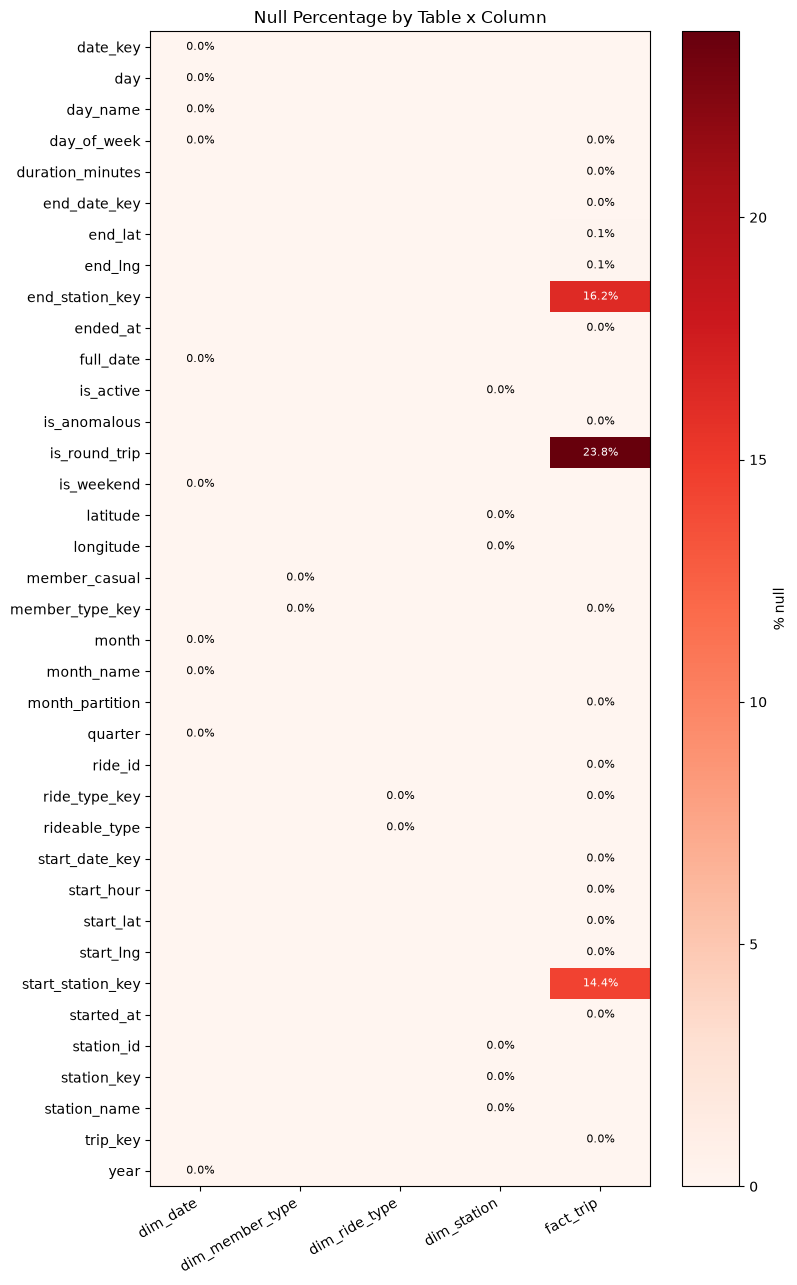

In [15]:
pivot = null_summary.pivot(index="column", columns="table", values="null_pct")

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(pivot))))
im = ax.imshow(pivot.fillna(-1).values, cmap="Reds", vmin=0, vmax=max(5, pivot.max().max()), aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
                     fontsize=8, color="white" if val > pivot.max().max()/2 else "black")
ax.set_title("Null Percentage by Table x Column")
fig.colorbar(im, ax=ax, label="% null")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FOLDER, "missing_value_heatmap.png"), dpi=150)
plt.show()


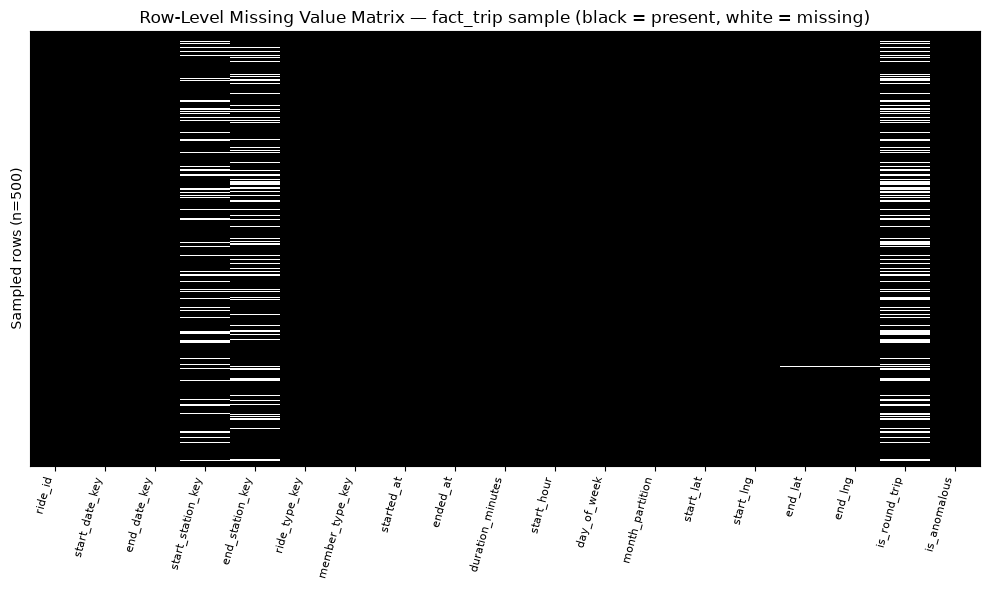

In [16]:
sample_n = min(500, len(fact))
sample_cols = [c for c in fact.columns if c not in ("trip_key",)]
sample = fact[sample_cols].sample(n=sample_n, random_state=42).reset_index(drop=True) if sample_n else fact[sample_cols]
presence = sample.notna().astype(int)

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(presence.values, cmap="Greys", aspect="auto", interpolation="nearest")
ax.set_xticks(range(len(presence.columns)))
ax.set_xticklabels(presence.columns, rotation=75, ha="right", fontsize=8)
ax.set_yticks([])
ax.set_ylabel(f"Sampled rows (n={sample_n})")
ax.set_title("Row-Level Missing Value Matrix — fact_trip sample (black = present, white = missing)")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FOLDER, "missing_value_matrix_rows.png"), dpi=150)
plt.show()


## Step 4 — Composite Data Quality Score

Rolls every check up into five standard data-quality dimensions, each scored 0–100
(`100 - % of rows affected`, floored at 0), then combined into a single weighted score:

| Dimension    | Weight | Driven by |
|---|---|---|
| Uniqueness   | 20% | duplicate `ride_id` rate |
| Completeness | 20% | critical-column null rate |
| Validity     | 25% | invalid timestamps + non-positive/mismatched durations + impossible coordinates |
| Consistency  | 20% | orphaned foreign keys + derived-field mismatches |
| Accuracy     | 15% | `is_anomalous` flag rate + calendar coverage gaps |


In [17]:
def score_from_pct(pct_affected: float) -> float:
    return max(0.0, 100.0 - pct_affected)

n = len(fact)

uniqueness_score = score_from_pct(findings["duplicate_ride_ids"]["pct_rows_affected"])
completeness_score = findings["data_completeness"]["overall_completeness_score"]

validity_bad_rows = (
    findings["invalid_timestamps"]["total_invalid_timestamp_rows"]
    + findings["negative_durations"]["non_positive_duration_rows"]
    + findings["negative_durations"]["duration_mismatch_vs_recomputed"]
    + findings["impossible_coordinates"]["impossible_lat_lng_rows"]
    + findings["impossible_coordinates"]["null_island_0_0_rows"]
)
validity_pct = round(100 * validity_bad_rows / n, 4) if n else 0.0
validity_score = score_from_pct(validity_pct)

consistency_score = score_from_pct(findings["data_consistency"]["pct_rows_affected"])

anomalous_rate_pct = round(100 * fact["is_anomalous"].fillna(False).mean(), 4) if "is_anomalous" in fact else 0.0
calendar_gap_pct = round(
    100 * findings["data_completeness"]["missing_calendar_days_in_dim_date"]
    / max(1, (pd.to_datetime(findings["data_completeness"]["date_range"][1])
              - pd.to_datetime(findings["data_completeness"]["date_range"][0])).days + 1),
    4,
)
accuracy_score = score_from_pct(anomalous_rate_pct + calendar_gap_pct)

dimension_scores = {
    "Uniqueness": round(uniqueness_score, 2),
    "Completeness": round(completeness_score, 2),
    "Validity": round(validity_score, 2),
    "Consistency": round(consistency_score, 2),
    "Accuracy": round(accuracy_score, 2),
}
weights = {"Uniqueness": 0.20, "Completeness": 0.20, "Validity": 0.25, "Consistency": 0.20, "Accuracy": 0.15}

overall_score = round(sum(dimension_scores[k] * weights[k] for k in weights), 2)

def grade_for(score):
    if score >= 90: return "A"
    if score >= 80: return "B"
    if score >= 70: return "C"
    if score >= 60: return "D"
    return "F"

overall_grade = grade_for(overall_score)

findings["quality_score"] = {
    "dimension_scores": dimension_scores,
    "weights": weights,
    "overall_score": overall_score,
    "overall_grade": overall_grade,
}

score_df = pd.DataFrame({
    "dimension": list(dimension_scores.keys()),
    "score": list(dimension_scores.values()),
    "weight": [weights[k] for k in dimension_scores],
})
display(score_df)
print(f"\nOVERALL DATA QUALITY SCORE: {overall_score} / 100  (Grade {overall_grade})")


,dimension,score,weight
0,Uniqueness,100.00,0.20
1,Completeness,94.90,0.20
2,Validity,100.00,0.25
3,Consistency,63.60,0.20
4,Accuracy,97.55,0.15



OVERALL DATA QUALITY SCORE: 91.33 / 100  (Grade A)


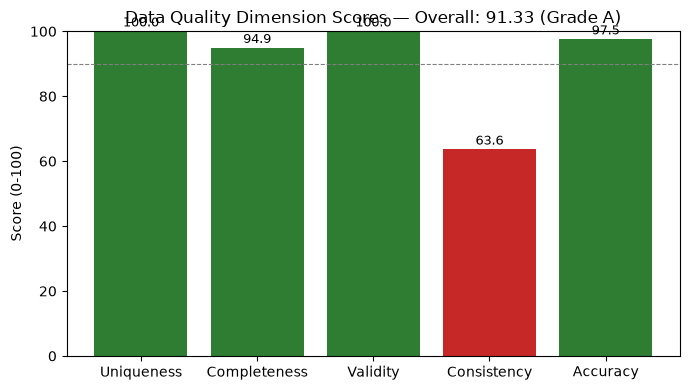

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#2e7d32" if s >= 90 else "#f9a825" if s >= 70 else "#c62828" for s in dimension_scores.values()]
bars = ax.bar(dimension_scores.keys(), dimension_scores.values(), color=colors)
ax.set_ylim(0, 100)
ax.set_ylabel("Score (0-100)")
ax.set_title(f"Data Quality Dimension Scores — Overall: {overall_score} (Grade {overall_grade})")
ax.axhline(90, color="grey", linestyle="--", linewidth=0.8)
for b, s in zip(bars, dimension_scores.values()):
    ax.text(b.get_x() + b.get_width()/2, s + 1.5, f"{s:.1f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FOLDER, "quality_score_breakdown.png"), dpi=150)
plt.show()


## Step 5 — Data Quality Report

Compiles every finding above into a single structured report and writes it to disk in three formats: a human-readable Markdown report, a flat CSV of metrics, and a full-detail JSON.

In [19]:
def build_markdown_report() -> str:
    lines = []
    lines.append(f"# Divvy Data Quality Report")
    lines.append(f"**Run timestamp (UTC):** {RUN_TIMESTAMP}  ")
    lines.append(f"**Rows assessed (fact_trip):** {len(fact):,}  ")
    lines.append(f"**Overall Quality Score:** {overall_score} / 100 (Grade {overall_grade})\n")

    lines.append("## Table Row Counts")
    for tname, tdf in tables.items():
        lines.append(f"- `{tname}`: {len(tdf):,} rows")
    lines.append("")

    lines.append("## Check Results\n")
    lines.append("| # | Check | Key Metric | % Rows Affected | Verdict |")
    lines.append("|---|---|---|---|---|")
    check_rows = [
        (1, "Duplicate ride IDs", f"{findings['duplicate_ride_ids']['duplicate_rows_total']:,} duplicate rows",
         findings['duplicate_ride_ids']['pct_rows_affected'], findings['duplicate_ride_ids']['verdict']),
        (2, "Missing stations",
         f"{findings['missing_stations']['null_start_station_key'] + findings['missing_stations']['null_end_station_key']:,} null station refs",
         findings['missing_stations']['pct_rows_affected'], findings['missing_stations']['verdict']),
        (3, "Invalid timestamps", f"{findings['invalid_timestamps']['total_invalid_timestamp_rows']:,} invalid rows",
         findings['invalid_timestamps']['pct_rows_affected'], findings['invalid_timestamps']['verdict']),
        (4, "Negative ride durations",
         f"{findings['negative_durations']['non_positive_duration_rows']:,} non-positive + {findings['negative_durations']['duration_mismatch_vs_recomputed']:,} mismatched",
         findings['negative_durations']['pct_rows_affected'], findings['negative_durations']['verdict']),
        (5, "Impossible coordinates",
         f"{findings['impossible_coordinates']['impossible_lat_lng_rows']:,} impossible + {findings['impossible_coordinates']['null_island_0_0_rows']:,} (0,0)",
         findings['impossible_coordinates']['pct_rows_affected'], findings['impossible_coordinates']['verdict']),
        (9, "Data consistency", f"{findings['data_consistency']['total_consistency_issues']:,} issues",
         findings['data_consistency']['pct_rows_affected'], findings['data_consistency']['verdict']),
    ]
    for n_, check, metric, pct, verd in check_rows:
        lines.append(f"| {n_} | {check} | {metric} | {pct}% | {verd} |")
    lines.append("")

    lines.append("## Null Percentages (columns with any nulls)\n")
    lines.append(null_summary[null_summary['null_pct'] > 0].to_markdown(index=False))
    lines.append("")

    lines.append("## Cardinality (fact_trip)\n")
    lines.append(cardinality.to_markdown())
    lines.append("")

    lines.append("## Data Completeness\n")
    lines.append(f"- Overall completeness score: **{findings['data_completeness']['overall_completeness_score']}%**")
    lines.append(f"- Missing calendar days in `dim_date`: {findings['data_completeness']['missing_calendar_days_in_dim_date']}")
    lines.append(f"- Days with zero recorded rides: {findings['data_completeness']['days_with_zero_rides']}")
    lines.append(f"- Date range assessed: {findings['data_completeness']['date_range'][0]} to {findings['data_completeness']['date_range'][1]}")
    lines.append("")

    lines.append("## Data Quality Score Breakdown\n")
    lines.append(score_df.to_markdown(index=False))
    lines.append("")
    lines.append(f"**Overall: {overall_score} / 100 — Grade {overall_grade}**")

    return "\n".join(lines)


report_md = build_markdown_report()
display(Markdown(report_md))


# Divvy Data Quality Report
**Run timestamp (UTC):** 2026-08-16T22:16:18+00:00  
**Rows assessed (fact_trip):** 1,000,000  
**Overall Quality Score:** 91.33 / 100 (Grade A)

## Table Row Counts
- `fact_trip`: 1,000,000 rows
- `dim_date`: 943 rows
- `dim_station`: 3,918 rows
- `dim_ride_type`: 3 rows
- `dim_member_type`: 2 rows

## Check Results

| # | Check | Key Metric | % Rows Affected | Verdict |
|---|---|---|---|---|
| 1 | Duplicate ride IDs | 0 duplicate rows | 0.0% | PASS |
| 2 | Missing stations | 306,099 null station refs | 23.8376% | FAIL |
| 3 | Invalid timestamps | 0 invalid rows | 0.0% | PASS |
| 4 | Negative ride durations | 0 non-positive + 45 mismatched | 0.0045% | PASS |
| 5 | Impossible coordinates | 0 impossible + 0 (0,0) | 0.0% | PASS |
| 9 | Data consistency | 364,011 issues | 36.4011% | FAIL |

## Null Percentages (columns with any nulls)

| table     | column            |   n_rows |   n_null |   null_pct |
|:----------|:------------------|---------:|---------:|-----------:|
| fact_trip | is_round_trip     |  1000000 |   238376 |     23.838 |
| fact_trip | end_station_key   |  1000000 |   162107 |     16.211 |
| fact_trip | start_station_key |  1000000 |   143992 |     14.399 |
| fact_trip | end_lat           |  1000000 |     1463 |      0.146 |
| fact_trip | end_lng           |  1000000 |     1463 |      0.146 |

## Cardinality (fact_trip)

|                   |   n_unique |   n_rows |   uniqueness_ratio |
|:------------------|-----------:|---------:|-------------------:|
| ride_id           |      1e+06 |    1e+06 |             1      |
| start_station_key |   1329     |    1e+06 |             0.0013 |
| end_station_key   |   1333     |    1e+06 |             0.0013 |
| ride_type_key     |      2     |    1e+06 |             0      |
| member_type_key   |      2     |    1e+06 |             0      |
| start_hour        |     24     |    1e+06 |             0      |
| day_of_week       |      7     |    1e+06 |             0      |
| month_partition   |      4     |    1e+06 |             0      |

## Data Completeness

- Overall completeness score: **94.9%**
- Missing calendar days in `dim_date`: 0
- Days with zero recorded rides: 821
- Date range assessed: 2024-01-01 to 2026-07-31

## Data Quality Score Breakdown

| dimension    |   score |   weight |
|:-------------|--------:|---------:|
| Uniqueness   |  100    |     0.2  |
| Completeness |   94.9  |     0.2  |
| Validity     |  100    |     0.25 |
| Consistency  |   63.6  |     0.2  |
| Accuracy     |   97.55 |     0.15 |

**Overall: 91.33 / 100 — Grade A**

In [20]:
# Persist all three report formats
md_path = os.path.join(REPORTS_FOLDER, "data_quality_report.md")
json_path = os.path.join(REPORTS_FOLDER, "data_quality_report.json")
csv_path = os.path.join(REPORTS_FOLDER, "data_quality_metrics.csv")

with open(md_path, "w", encoding="utf-8") as f:
    f.write(report_md)

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(findings, f, indent=2, default=str)

# Flatten findings into one metrics-per-row CSV for spreadsheet/BI consumption
flat_rows = []
for check, metrics in findings.items():
    if not isinstance(metrics, dict):
        continue
    for k, v in metrics.items():
        if isinstance(v, (dict, list)):
            continue
        flat_rows.append({"check": check, "metric": k, "value": v})
pd.DataFrame(flat_rows).to_csv(csv_path, index=False)

print(f"Markdown report : {md_path}")
print(f"JSON report     : {json_path}")
print(f"CSV metrics     : {csv_path}")
print(f"Charts          : {REPORTS_FOLDER}")


Markdown report : G:\\My Drive\\divvy_tripdata\data_quality_reports\data_quality_report.md
JSON report     : G:\\My Drive\\divvy_tripdata\data_quality_reports\data_quality_report.json
CSV metrics     : G:\\My Drive\\divvy_tripdata\data_quality_reports\data_quality_metrics.csv
Charts          : G:\\My Drive\\divvy_tripdata\data_quality_reports


## Summary

This assessment re-derives data-quality metrics straight from the warehouse rather than trusting
the ETL pipeline's self-reported counters, so it will also surface issues introduced after loading.
Re-run this notebook after every load (or on a schedule) to track the **Quality Score** over time —
a sustained drop is an early signal that something upstream (Divvy's export format, the ETL logic in
`03_data_cleaning_and_loading.ipynb`, or a manual edit) needs attention.